# 📩 SMS Spam Detection using Machine Learning

## 📌 Опис проєкту

Цей проєкт реалізує систему класифікації SMS-повідомлень на два класи:
- **spam** (небажані повідомлення)
- **ham** (звичайні повідомлення)

Мета проєкту — пройти повний цикл задачі машинного навчання: від аналізу даних до побудови та оцінки моделей.

---

## 🎯 Мета

- Проаналізувати текстові дані SMS-повідомлень
- Виконати очищення та підготовку тексту
- Перетворити текст у числові ознаки (TF-IDF)
- Побудувати моделі класифікації
- Порівняти ефективність алгоритмів

---

## 📊 Датасет

Використано датасет:

📌 SMS Spam Collection Dataset  
https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

In [80]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Грицюк
[nltk_data]     Ірина\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 🧹 Етапи роботи

### 1. Завантаження та аналіз даних
- Перевірка структури датасету
- Аналіз розподілу класів (spam/ham)
- Аналіз довжини повідомлень

In [35]:
df = pd.read_csv("data/spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df = df[['v1', 'v2']]

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [7]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

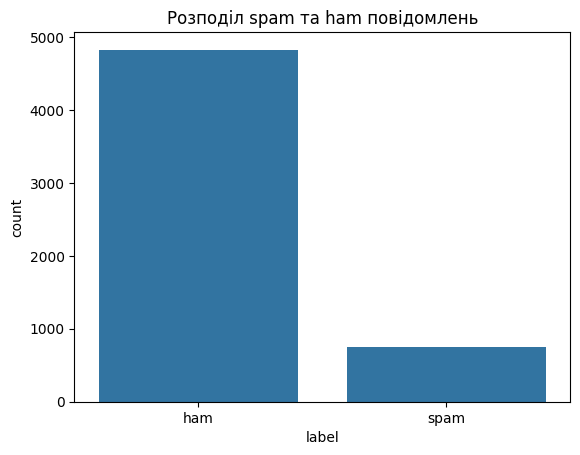

In [8]:
sns.countplot(data=df, x='label')
plt.title('Розподіл spam та ham повідомлень')
plt.show()

### 2. Feature Engineering
- Створення нової ознаки: довжина повідомлення

In [9]:
df['length'] = df['message'].apply(len)

df.head()

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


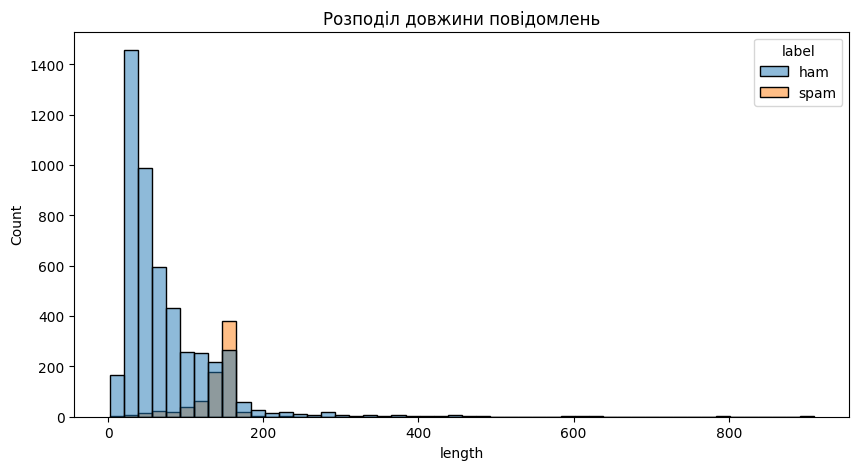

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='length', hue='label', bins=50)
plt.title('Розподіл довжини повідомлень')
plt.show()

In [11]:
df.groupby('label')['length'].mean()

label
ham      71.023627
spam    138.866131
Name: length, dtype: float64

In [74]:
print("Поточні стовпці:", df.columns.tolist())

if 'v1' in df.columns and 'v2' in df.columns:
    df = df[['v1', 'v2']] 
    df.columns = ['label', 'message']
    print("Стовпці успішно перейменовано на 'label' та 'message'")

df.head()

Поточні стовпці: ['label', 'message', 'clean_message']


,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


### 3. Попередня обробка тексту
- Переведення у нижній регістр
- Видалення пунктуації
- Видалення stopwords
- Лематизація/очистка тексту

In [75]:
def clean_text(text):
    text = text.lower()
    
    text = re.sub(r'[^\w\s]', '', text)
    
    words = text.split()
    
    words = [word for word in words if word not in stopwords.words('english')]
    
    return " ".join(words)

In [76]:
df['clean_message'] = df['message'].apply(clean_text)

print(df[['message', 'clean_message']].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry 2 wkly comp win fa cup final tkts 2...  
3                u dun say early hor u c already say  
4        nah dont think goes usf lives around though  


In [77]:
from nltk.corpus import stopwords

In [78]:
def clean_text(text):
    text = text.lower()
    
    text = re.sub(r'[^\w\s]', '', text)
    
    words = text.split()
    
    words = [word for word in words if word not in stopwords.words('english')]
    
    return " ".join(words)

In [79]:
df['clean_message'] = df['message'].apply(clean_text)

print(df[['message', 'clean_message']].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry 2 wkly comp win fa cup final tkts 2...  
3                u dun say early hor u c already say  
4        nah dont think goes usf lives around though  


### 4. Векторизація тексту
Використано **TF-IDF (Term Frequency-Inverse Document Frequency)** для перетворення тексту у числовий формат, який зрозумілий моделям машинного навчання.

In [62]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['clean_message'])

y = df['label']

In [42]:
X.shape

(5572, 9403)

## 🤖 Моделі
Було використано 2 алгоритми для порівняння:
1. **Multinomial Naive Bayes**
2. **Logistic Regression**

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [64]:
print(X_train.shape)
print(X_test.shape)

(4457, 9403)
(1115, 9403)


In [65]:
nb_model = MultinomialNB()

In [66]:
nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [67]:
y_pred_nb = nb_model.predict(X_test)

In [68]:
accuracy_score(y_test, y_pred_nb)

0.9659192825112107

In [69]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.75      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



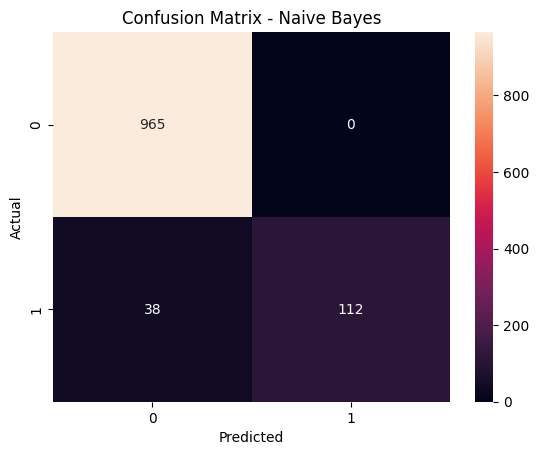

In [50]:
cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [51]:
lr_model = LogisticRegression(max_iter=1000)

In [52]:
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [53]:
y_pred_lr = lr_model.predict(X_test)

In [54]:
accuracy_score(y_test, y_pred_lr)

0.9417040358744395

In [55]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         ham       0.94      1.00      0.97       965
        spam       0.96      0.59      0.73       150

    accuracy                           0.94      1115
   macro avg       0.95      0.79      0.85      1115
weighted avg       0.94      0.94      0.94      1115



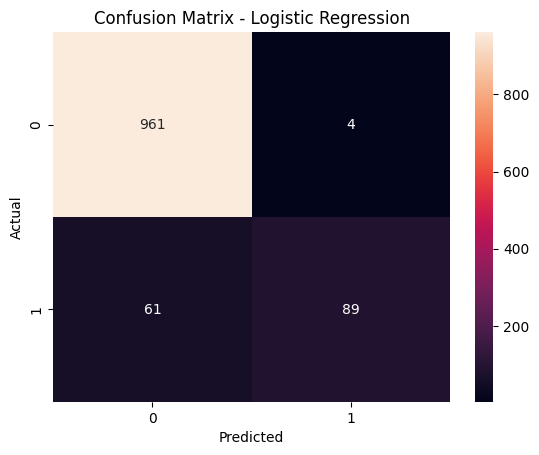

In [56]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [57]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [0.9659, 0.9417],
    'Spam Recall': [0.75, 0.59],
    'Spam F1': [0.85, 0.73]
})

results

,Model,Accuracy,Spam Recall,Spam F1
0,Naive Bayes,0.9659,0.75,0.85
1,Logistic Regression,0.9417,0.59,0.73


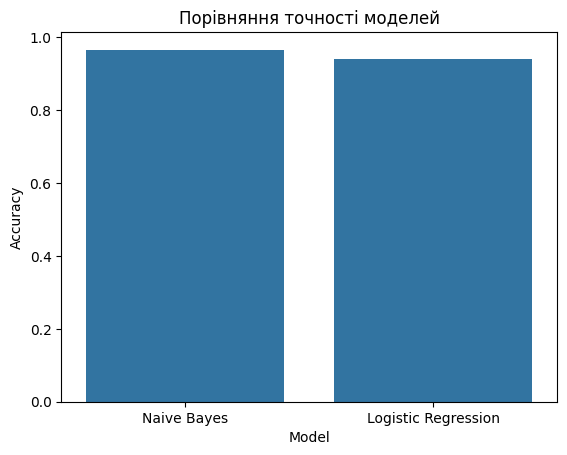

In [58]:
sns.barplot(data=results, x='Model', y='Accuracy')
plt.title('Порівняння точності моделей')
plt.show()

In [72]:
def predict_spam(new_message):
    processed = clean_text(new_message) 
    
    vectorized = vectorizer.transform([processed]) 
    
    prediction = nb_model.predict(vectorized) 
    
    return prediction[0]

In [73]:
test_1 = "WINNER! You have won a 1000$ prize. Call 0800 now to claim!"
print(f"SMS 1: {predict_spam(test_1)}")

test_2 = "Hey, are we still meeting for coffee at 5?"
print(f"SMS 2: {predict_spam(test_2)}")

SMS 1: spam
SMS 2: ham


## 📈 Результати

| Модель                | Accuracy | Spam Recall | Spam F1 |
|----------------------|----------|-------------|---------|
| Naive Bayes          | 96.6%    | 0.75        | 0.85    |
| Logistic Regression  | 94.2%    | 0.59        | 0.73    |

## 🏆 Висновок
Найкращий результат показала модель **Multinomial Naive Bayes**, яка продемонструвала вищу точність та кращу здатність виявляти spam-повідомлення. Це підтверджує ефективність простих ймовірнісних моделей для задач текстової класифікації.

## 🛠️ Використані технології
* Python (Pandas, Numpy, Scikit-learn, NLTK)
* Matplotlib, Seaborn (Візуалізація)
* Jupyter Notebook

## 🚀 Як запустити проєкт
1. Клонувати репозиторій.
2. Встановити залежності.
3. Запустити Jupyter Notebook та виконати всі клітинки (Restart & Run All).